In [283]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [285]:
#What was the total revenue generated by the company over the course of the year?
#Which product had the highest revenue? How much revenue did it generate?
#What was the average price of a product sold by the company?
#What was the total quantity of products sold by the company?
#Which category had the highest revenue? How much revenue did it generate?
#What was the average revenue per sale?
#What was the total revenue generated in each quarter of the year? (i.e. Q1, Q2, Q3, Q4)

In [287]:
df=pd.read_csv(r"C:\Users\Asus\Downloads\sales_data.csv")
df.head()

,date,product,category,price,quantity,revenue
0,2022-01-01,Smartphone,Electronics,600.0,10.0,6000.0
1,2022-01-01,Laptop,Electronics,1200.0,5.0,6000.0
2,2022-01-02,T-Shirt,Clothing,20.0,50.0,1000.0
3,2022-01-03,Headphones,Electronics,100.0,20.0,2000.0
4,2022-01-04,T-Shirt,Clothing,20.0,25.0,500.0


In [289]:
df.tail(5)

,date,product,category,price,quantity,revenue
364,2022-12-27,Watch,Accessories,150.0,5.0,750.0
365,2022-12-28,Coat,Clothing,100.0,5.0,500.0
366,2022-12-29,Headphones,Electronics,100.0,10.0,1000.0
367,2022-12-30,Smartphone,Electronics,600.0,11.0,6600.0
368,2022-12-31,Hoodie,Clothing,40.0,30.0,1200.0


In [291]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 369 entries, 0 to 368
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      369 non-null    object 
 1   product   369 non-null    object 
 2   category  369 non-null    object 
 3   price     367 non-null    float64
 4   quantity  368 non-null    float64
 5   revenue   368 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.4+ KB


In [293]:
df.isnull().sum()

date        0
product     0
category    0
price       2
quantity    1
revenue     1
dtype: int64

In [295]:
df.dropna()

,date,product,category,price,quantity,revenue
0,2022-01-01,Smartphone,Electronics,600.0,10.0,6000.0
1,2022-01-01,Laptop,Electronics,1200.0,5.0,6000.0
2,2022-01-02,T-Shirt,Clothing,20.0,50.0,1000.0
3,2022-01-03,Headphones,Electronics,100.0,20.0,2000.0
4,2022-01-04,T-Shirt,Clothing,20.0,25.0,500.0
...,...,...,...,...,...,...
364,2022-12-27,Watch,Accessories,150.0,5.0,750.0
365,2022-12-28,Coat,Clothing,100.0,5.0,500.0
366,2022-12-29,Headphones,Electronics,100.0,10.0,1000.0
367,2022-12-30,Smartphone,Electronics,600.0,11.0,6600.0


In [297]:
df = df.dropna(how='any',axis=0) 

In [299]:
df.isnull().sum()

date        0
product     0
category    0
price       0
quantity    0
revenue     0
dtype: int64

In [301]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 0 to 368
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      365 non-null    object 
 1   product   365 non-null    object 
 2   category  365 non-null    object 
 3   price     365 non-null    float64
 4   quantity  365 non-null    float64
 5   revenue   365 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.0+ KB


In [303]:
df.describe()

,price,quantity,revenue
count,365.000000,365.000000,365.000000
mean,210.191781,14.520548,2050.493151
std,227.043145,8.560883,1903.190865
min,20.000000,3.000000,300.000000
25%,50.000000,8.000000,800.000000
50%,100.000000,12.000000,1200.000000
75%,200.000000,20.000000,2400.000000
max,1200.000000,50.000000,7200.000000


In [305]:
df.index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       359, 360, 361, 362, 363, 364, 365, 366, 367, 368],
      dtype='int64', length=365)

In [307]:
df.shape

(365, 6)

In [309]:
#df.nlargest(n=5, keep='product')

In [311]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
364    False
365    False
366    False
367    False
368    False
Length: 365, dtype: bool

In [313]:
df.duplicated().sum()

1

In [315]:
df.drop_duplicates().sum()

date        2022-01-012022-01-012022-01-022022-01-032022-0...
product     SmartphoneLaptopT-ShirtHeadphonesT-ShirtWatchS...
category    ElectronicsElectronicsClothingElectronicsCloth...
price                                                 76680.0
quantity                                               5270.0
revenue                                              747230.0
dtype: object

In [317]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
364    False
365    False
366    False
367    False
368    False
Length: 365, dtype: bool

In [319]:
#df.fillna()

In [321]:
from datetime import datetime

In [323]:
my_string = '2019-10-31'
my_date = datetime.strptime(my_string, "%Y-%m-%d")# Create date object in given time format yyyy-mm-dd

In [325]:
print('Year: ', my_date.year)

Year:  2019


In [327]:
df['date']=pd.to_datetime(df['date'])

In [329]:
df['date'].dt.year

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
364    2022
365    2022
366    2022
367    2022
368    2022
Name: date, Length: 365, dtype: int32

In [331]:
xc=df['revenue'].sum()/df['date'].dt.year
xc

0      370.143422
1      370.143422
2      370.143422
3      370.143422
4      370.143422
          ...    
364    370.143422
365    370.143422
366    370.143422
367    370.143422
368    370.143422
Name: date, Length: 365, dtype: float64

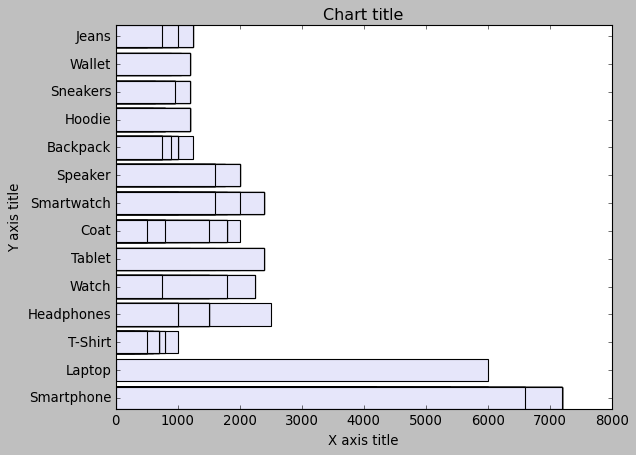

In [333]:
plt.barh(df['product'],df['revenue'],color=['#E6E6FA'])
plt.title('Chart title')
plt.xlabel('X axis title')
plt.ylabel('Y axis title') 

#Show the plot
plt.show()
#This chart improve that the highest reveue is the smartphone because one as the bar chart said with 7000 so that means that electronics categrory is the hight
#revue in the company

Text(0, 0.5, 'Y axis title')

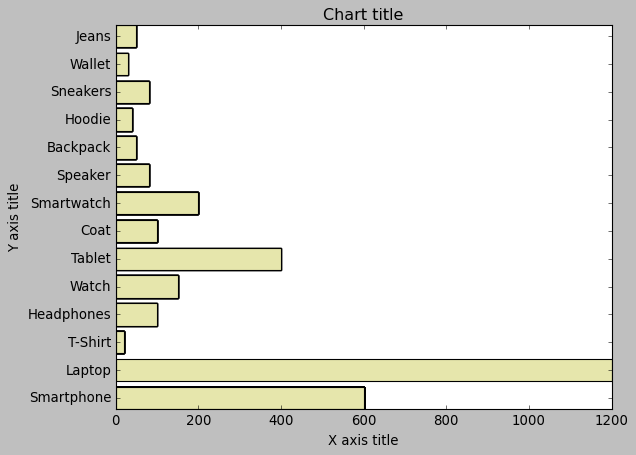

In [334]:
plt.barh(df['product'],df['price'],color=['#E6E6Ac'])
plt.title('Chart title')
plt.xlabel('X axis title')
plt.ylabel('Y axis title') 
# this graph represnt the highest product in the company as price is the laptop and smaertphone is cheaper thjan laptop

In [335]:
df['quantity'].mean()

14.520547945205479

In [336]:
1- What was the total revenue generated by the company over the course of the year?

Object `year` not found.


In [337]:
#labels = ['product', 'price', 'revenue']
#y = np.array([35, 25, 25, 15])
#plt.pie(y,labels=labels )
#plt.show()
#plt.axis('equal') # keep it a circle
#plt.show()

In [338]:
xg=df['price'].mean()
xg

210.1917808219178

In [339]:
#xcc=df['price'].mean()/df['product']


In [341]:
Total=df['revenue'].mean()
Total

2050.4931506849316

<Figure size 960x480 with 0 Axes>

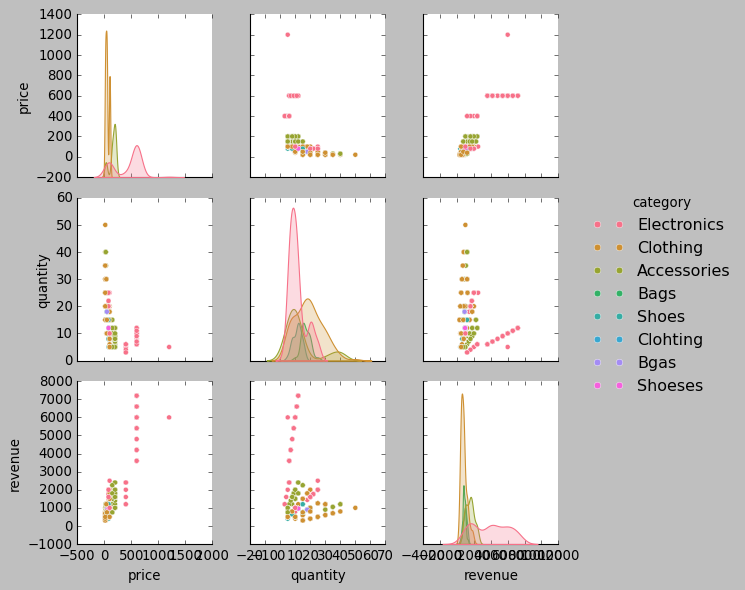

In [342]:
plt.figure(figsize=(12,6))
sns.pairplot(data=df,hue='category')
plt.show()


In [343]:
prohighest=df.nlargest(5,'revenue')['product']
prohighest
#That means in this result that smart phone has the highest revune

13     Smartphone
44     Smartphone
72     Smartphone
103    Smartphone
134    Smartphone
Name: product, dtype: object

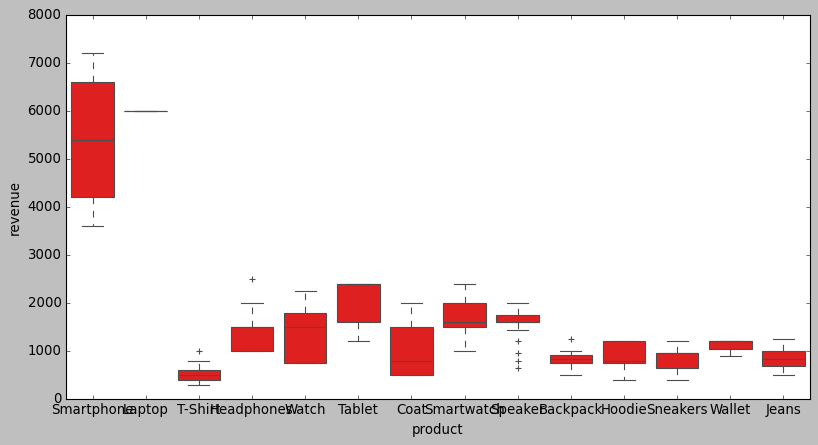

In [344]:
plt.figure(figsize=(12,6))
sns.boxplot(x='product',y='revenue',data=df,color='r')
plt.show()
#this graph improve that smartphone is the highest revenue

In [345]:
#Which category had the highest revenue? How much revenue did it generate?

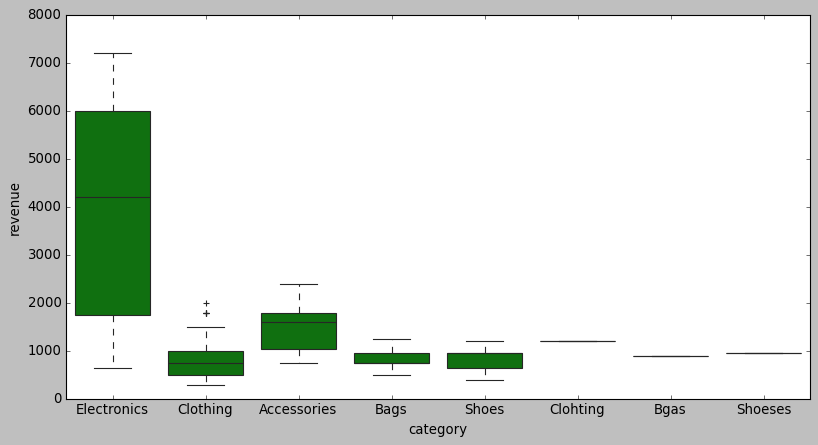

In [346]:
plt.figure(figsize=(12,6))
sns.boxplot(x='category',y='revenue',data=df,color='g')
plt.show()
# In this graph improve that the highest category is electronics

In [347]:
#totalofcategroy= df['category']='Electronics' 	
#totalofcategroy
 #totalofcategroy1=df.column(['category']=='Electronics' )

In [352]:
#What was the total quantity of products sold by the company?

In [356]:
totalq=df['quantity'].sum()
totalq

5300.0

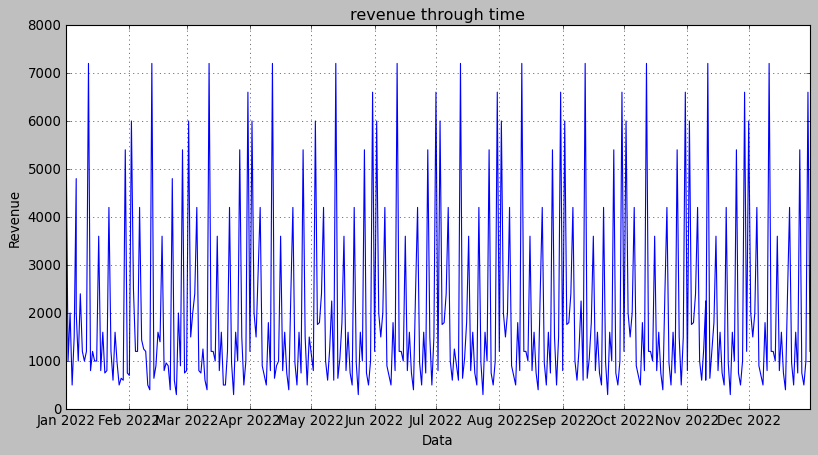

In [357]:
plt.figure(figsize=(12,6))
plt.plot(df['date'],df['revenue'],color='b')
plt.title('revenue through time')
plt.xlabel('Data')
plt.ylabel('Revenue')
plt.style.use('classic') 

plt.grid()
plt.show()
#In this graph it summarize the revenue through months 

In [358]:
#What was the total revenue generated in each quarter of the year?

In [359]:
revenueofquarterofyear = df.groupby(df['date'].dt.to_period('Q'))['revenue'].mean()
revenueofquarterofyear

date
2022Q1    1979.347826
2022Q2    1992.921348
2022Q3    2147.582418
2022Q4    2080.967742
Freq: Q-DEC, Name: revenue, dtype: float64

In [360]:
revenueofquarterofyear = df.groupby(df['date'].dt.to_period('Q'))['revenue'].sum()
revenueofquarterofyear

date
2022Q1    182100.0
2022Q2    177370.0
2022Q3    195430.0
2022Q4    193530.0
Freq: Q-DEC, Name: revenue, dtype: float64

In [361]:
x=revenueofquarterofyear


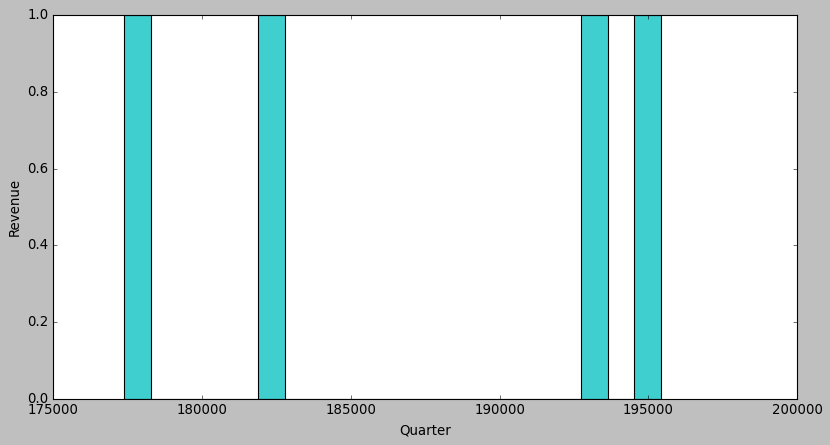

In [362]:
plt.figure(figsize=(12,6))
sns.histplot(x,color='c',bins=20)
plt.xlabel("Quarter")
plt.ylabel('Revenue')
plt.show()

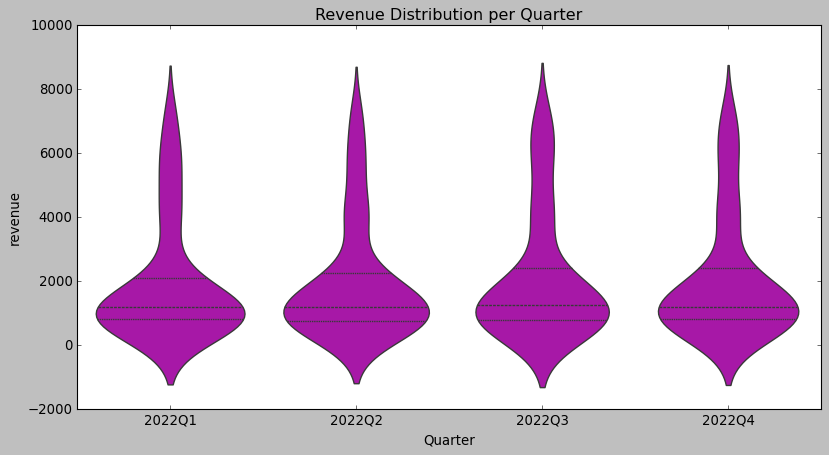

In [388]:
df['Quarter'] = df['date'].dt.to_period('Q')
plt.figure(figsize=(12,6))
sns.violinplot(x='Quarter', y='revenue', data=df, inner='quartile',color='m')
plt.title("Revenue Distribution per Quarter")
plt.show()